In [3]:
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o-mini')

In [1]:
from typing import Annotated # 타입힌트
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

graph_builder = StateGraph(State)

In [4]:
def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.
    
    매개변수:
    state(State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
    
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
        형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [5]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

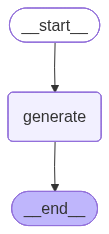

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
response = graph.invoke({"messages": ["안녕하세요, 저는 신호용입니다."]})

print(type(response))

response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요, 저는 신호용입니다.', additional_kwargs={}, response_metadata={}, id='1fded23b-e5ec-4e82-a219-5aaea28379df'),
  AIMessage(content='안녕하세요, 신호용님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 16, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b37d70806b', 'id': 'chatcmpl-Dey0ynxwcu6M8XFpTs29ihdQsdzmK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e202b-9300-79c3-aeea-6f50617b8a89-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 21, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [8]:
response["messages"].append("제 이름을 보면 어떤 사람같나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요, 저는 신호용입니다.', additional_kwargs={}, response_metadata={}, id='1fded23b-e5ec-4e82-a219-5aaea28379df'),
  AIMessage(content='안녕하세요, 신호용님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 16, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b37d70806b', 'id': 'chatcmpl-Dey0ynxwcu6M8XFpTs29ihdQsdzmK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e202b-9300-79c3-aeea-6f50617b8a89-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 21, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [9]:
inputs = {"messages": [("human","한국주식시장 미래에 대해서 자세히 알려줘.")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국 주식시장의 미래에 대한 전망은 여러 가지 요인에 따라 달라질 수 있습니다. 다음은 그와 관련된 몇 가지 주요 사항입니다.

1. **경제 성장**: 한국 경제는 디지털 혁신과 제조업의 강점을 바탕으로 지속 성장이 기대됩니다. 특히 반도체, 바이오, 전기차 관련 산업은 글로벌 수요 증가와 함께 성장 가능성이 높습니다.

2. **정치적 안정**: 정치적 안정은 투자자 신뢰에 중요한 요소입니다. 정부의 경제 정책, 규제 변화, 무역 정책 등이 주식시장에 큰 영향을 미칠 수 있습니다.

3. **글로벌 경제와의 관계**: 한국은 수출 중심의 경제 구조를 가지고 있어 글로벌 경제 상황에 큰 영향을 받습니다. 주요 교역국의 경제 상황(미국, 중국 등)과 국제 무역 정책에 따라 한국 주식시장은 변동성이 클 수 있습니다.

4. **기술 혁신**: 한국의 IT 및 기술 기업들은 세계적인 경쟁력을 가지고 있습니다. AI, 빅데이터, 클라우드 컴퓨팅 등의 분야에서 기술 혁신이 이루어지면 주식시장에 긍정적인 영향을 미칠 가능성이 높습니다.

5. **ESG 투자**: 환경, 사회, 지배구조(ESG) 관련 기업에 대한 투자가 증가하고 있으며, 이는 한국 주식시장에서도 더욱 중요해질 것입니다. 기업들이 ESG 기준을 충족시키기 위해 노력할 경우, 해당 기업들의 주가에 긍정적인 영향을 미칠 수 있습니다.

6. **금융 정책**: 중앙은행의 기준 금리 및 통화 정책도 주식시장에 영향 미칩니다. 금리가 낮아지면 투자자들이 주식 시장으로 이동할 가능성이 높아집니다.

7. **국제 유가 및 원자재 가격**: 원자재 수출입에 의존하는 한국 경제에 유가 및 기타 원자재 가격의 변동은 주식시장에 직접적인 영향을 미칠 수 있습니다.

종합적으로, 한국 주식시장은 여러 요인에 의해 영향을 받기 때문에 미래를 예측하기 어려울 수 있습니다. 그러나 기술 혁신과 글로벌 경제 동향에 주목하며, 안정적이고 지속 가능한 성장을 이루는 기업들에 투자하는 것이 중요할 것입니다. 투자에 대한 결정을 내릴 